# 09 — SHAP Explanations

This notebook uses **SHAP** (SHapley Additive exPlanations) to explain *why* each model
flags a UE as at risk of handover.  We go beyond the pre-computed static plots in
`reports/shap/` to produce:

| Section | Content |
|---------|--------|
| 1 | Feature importance — compare LR / RF / XGBoost side-by-side |
| 2 | Beeswarm (SHAP distribution) for XGBoost |
| 3 | Feature dependency plots — top predictors |
| 4 | Waterfall — explain one TP and one FP prediction |
| 5 | Temporal SHAP — track a single UE's explanation over time |
| 6 | Key findings |

**Prerequisites:** `python run_pipeline.py` (phases 3 + 4 + 5)

In [1]:
import sys, os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import shap

os.environ.setdefault("OMP_NUM_THREADS", "1")
warnings.filterwarnings("ignore")

ROOT = Path("../")
sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})
shap.initjs()   # enable JS plots in notebook

In [2]:
# ── Load test set + feature metadata ─────────────────────────────────────────
with open(ROOT / "data/processed/meta.json") as f:
    meta = json.load(f)

test = pd.read_csv(ROOT / "data/processed/test.csv")
feat_cols = [c for c in meta["feature_cols"] if c in test.columns]

X_test = test[feat_cols].fillna(0).values
y_test = test["handover_soon"].values

# ── Load models ───────────────────────────────────────────────────────────────
lr  = joblib.load(ROOT / "models/logistic_regression.pkl")
rf  = joblib.load(ROOT / "models/random_forest.pkl")
xgb = joblib.load(ROOT / "models/xgboost.pkl")

print(f"Test set: {X_test.shape[0]} rows × {X_test.shape[1]} features")
print(f"Positive rate: {y_test.mean():.1%}")

Test set: 4050 rows × 86 features
Positive rate: 9.5%


In [3]:
# ── Stratified background sample (500 rows) ───────────────────────────────────
rng = np.random.default_rng(42)
pos_idx = np.where(y_test == 1)[0]
neg_idx = np.where(y_test == 0)[0]
bg_idx  = np.concatenate([
    rng.choice(pos_idx, min(250, len(pos_idx)), replace=False),
    rng.choice(neg_idx, min(250, len(neg_idx)), replace=False),
])
X_bg  = X_test[bg_idx]
y_bg  = y_test[bg_idx]

X_bg_f32 = X_bg.astype(np.float32)   # XGBoost needs float32
print(f"Background sample: {len(X_bg)} rows  ({y_bg.mean():.1%} positive)")

Background sample: 500 rows  (50.0% positive)


## 1 · Global feature importance — all three models side-by-side

Mean |SHAP| ranked for the top 15 features per model.  A feature high on all three
charts is a *robust* predictor regardless of model architecture.

In [4]:
print("Computing SHAP values (LR + RF + XGBoost)…")

# Logistic Regression
lr_explainer  = shap.LinearExplainer(lr, shap.maskers.Independent(X_bg, max_samples=500))
lr_shap       = lr_explainer.shap_values(X_bg)

# Random Forest
rf_explainer  = shap.TreeExplainer(rf)
rf_shap_raw   = rf_explainer.shap_values(X_bg)
rf_shap       = rf_shap_raw[1] if isinstance(rf_shap_raw, list) else (
                rf_shap_raw[:, :, 1] if rf_shap_raw.ndim == 3 else rf_shap_raw)

# XGBoost
xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap      = xgb_explainer.shap_values(X_bg_f32)
if isinstance(xgb_shap, list): xgb_shap = xgb_shap[1]
if xgb_shap.ndim == 3:         xgb_shap = xgb_shap[:, :, 1]

print("Done.")

Computing SHAP values (LR + RF + XGBoost)…
Done.


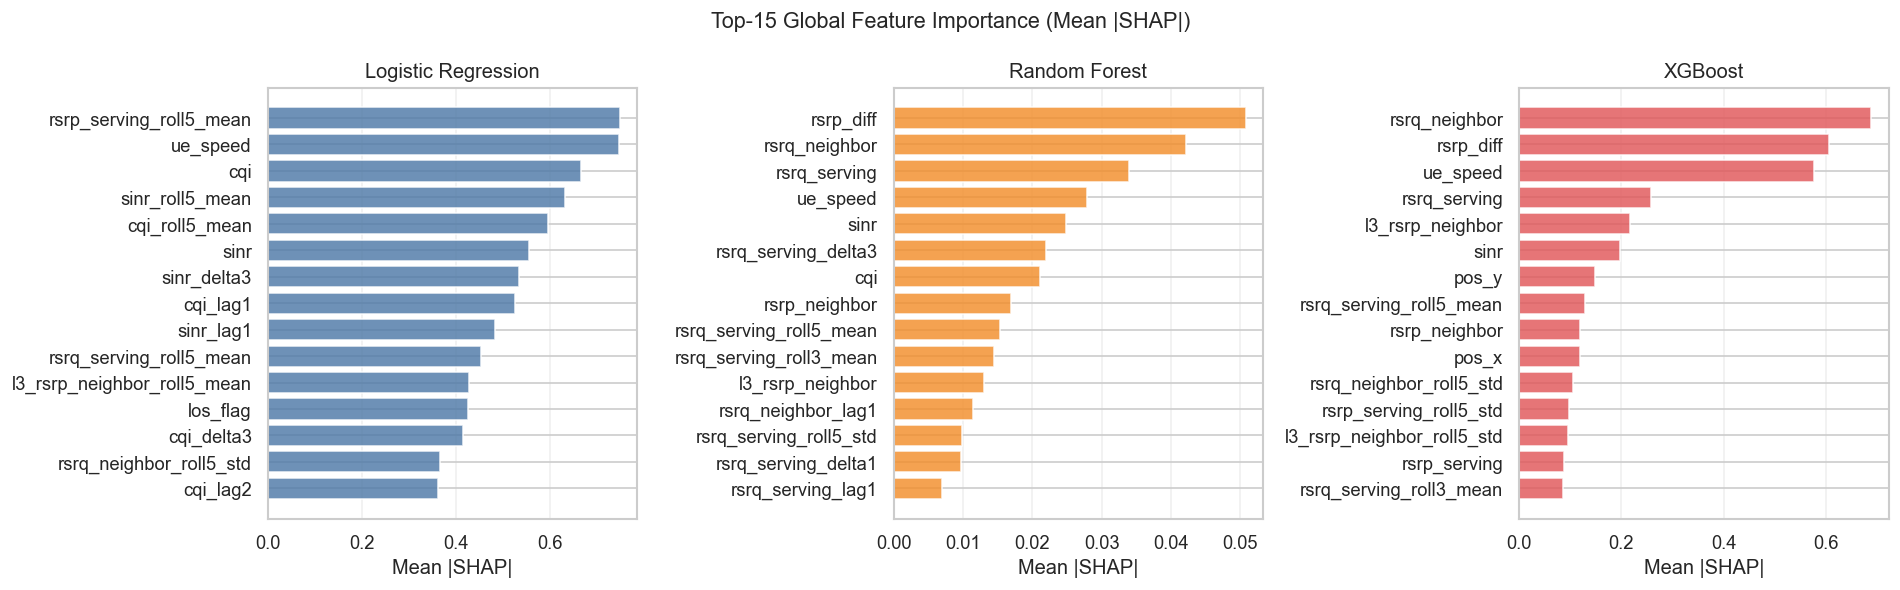

In [5]:
TOP = 15
model_data = [
    ("Logistic Regression", lr_shap,  "#4e79a7"),
    ("Random Forest",       rf_shap,  "#f28e2b"),
    ("XGBoost",             xgb_shap, "#e15759"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, sv, color) in zip(axes, model_data):
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:TOP][::-1]   # ascending for barh
    ax.barh([feat_cols[i] for i in top_idx], mean_abs[top_idx],
            color=color, alpha=0.82)
    ax.set_xlabel("Mean |SHAP|")
    ax.set_title(name)
    ax.grid(axis="x", alpha=0.3)

fig.suptitle(f"Top-{TOP} Global Feature Importance (Mean |SHAP|)", fontsize=13)
plt.tight_layout()
plt.show()

### Consensus importance across all three models
Average the mean |SHAP| rank across LR, RF, and XGBoost to find universally important features.

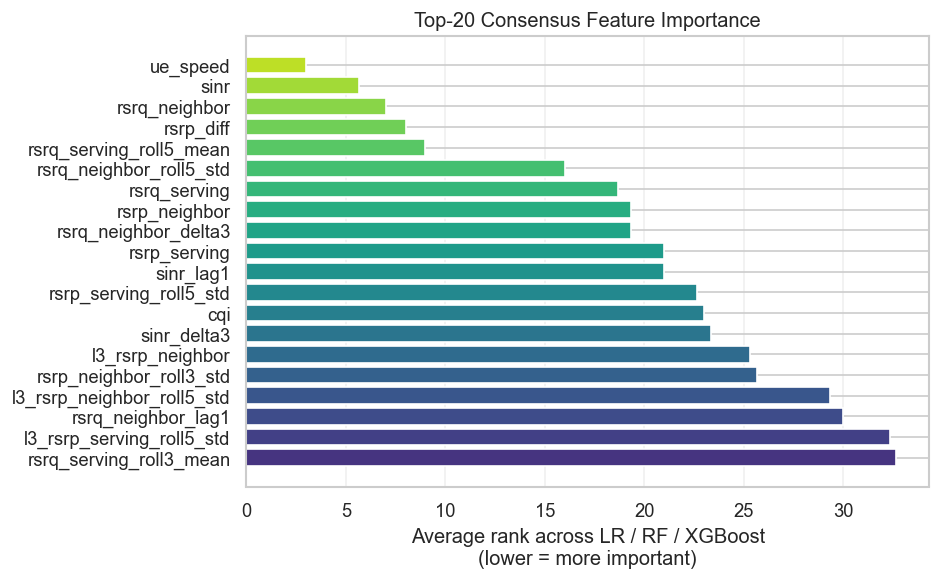

In [6]:
def rank_series(sv):
    mean_abs = np.abs(sv).mean(axis=0)
    ranks = pd.Series(mean_abs, index=feat_cols).rank(ascending=False)
    return ranks

consensus = (rank_series(lr_shap) + rank_series(rf_shap) + rank_series(xgb_shap)) / 3
top_consensus = consensus.nsmallest(20)   # lowest avg rank = most important

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis_r(np.linspace(0.1, 0.85, len(top_consensus)))
ax.barh(top_consensus.index[::-1], top_consensus.values[::-1], color=colors[::-1])
ax.set_xlabel("Average rank across LR / RF / XGBoost\n(lower = more important)")
ax.set_title("Top-20 Consensus Feature Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 2 · Beeswarm — XGBoost SHAP distribution

Each dot is one test sample.  
**x-axis** = SHAP value (right → pushes toward *HO soon*)  
**colour** = actual feature value (red = high, blue = low)

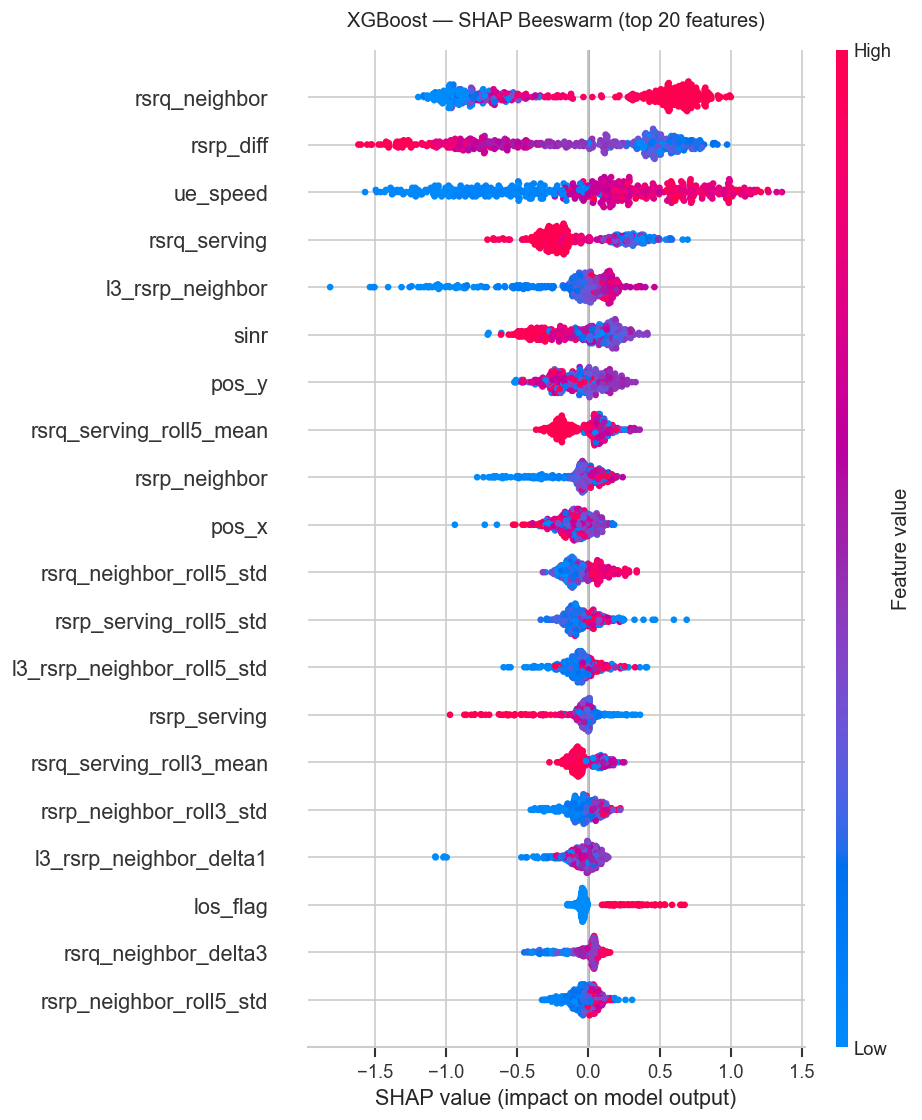

In [7]:
mean_abs_xgb = np.abs(xgb_shap).mean(axis=0)
top20_idx    = np.argsort(mean_abs_xgb)[::-1][:20]

expl = shap.Explanation(
    values        = xgb_shap[:, top20_idx],
    base_values   = np.zeros(len(xgb_shap)),
    data          = X_bg_f32[:, top20_idx],
    feature_names = [feat_cols[i] for i in top20_idx],
)

plt.figure(figsize=(9, 6))
shap.plots.beeswarm(expl, show=False, max_display=20)
plt.title("XGBoost — SHAP Beeswarm (top 20 features)", pad=14)
plt.tight_layout()
plt.show()

## 3 · Feature dependency plots

For the top-2 XGBoost features: SHAP value vs raw feature value, coloured by the
second-most interacting feature (auto-detected by SHAP).

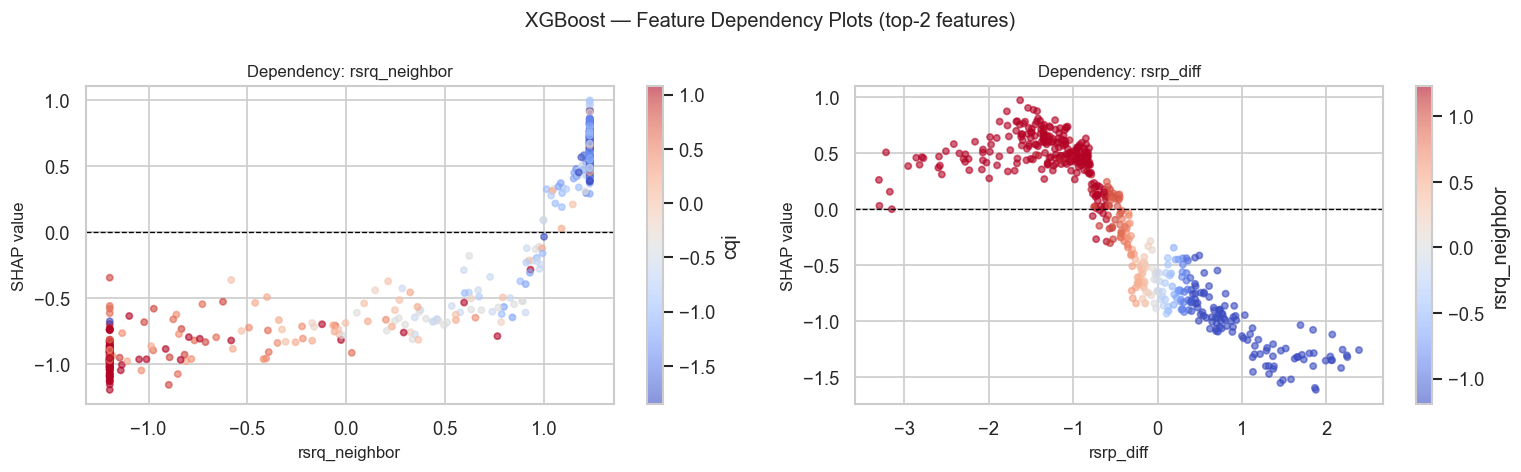

In [8]:
top2 = [feat_cols[i] for i in np.argsort(mean_abs_xgb)[::-1][:2]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat in zip(axes, top2):
    fi = feat_cols.index(feat)
    # Find interaction feature (highest |correlation| with SHAP values)
    corrs = [abs(np.corrcoef(xgb_shap[:, fi], X_bg[:, j])[0,1])
             for j in range(X_bg.shape[1]) if j != fi]
    interact_i = int(np.argmax(corrs))
    if interact_i >= fi: interact_i += 1   # offset back past fi
    interact_feat = feat_cols[interact_i]

    scatter = ax.scatter(
        X_bg[:, fi], xgb_shap[:, fi],
        c=X_bg[:, interact_i],
        cmap="coolwarm", alpha=0.6, s=14,
    )
    plt.colorbar(scatter, ax=ax, label=interact_feat[:30])
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel("SHAP value", fontsize=10)
    ax.set_title(f"Dependency: {feat[:35]}", fontsize=10)

fig.suptitle("XGBoost — Feature Dependency Plots (top-2 features)", fontsize=12)
plt.tight_layout()
plt.show()

## 4 · Waterfall plots — explaining individual predictions

We compare two cases:
- **True Positive (TP):** model correctly predicted *HO soon = 1*
- **False Positive (FP):** model incorrectly flagged a non-handover sample

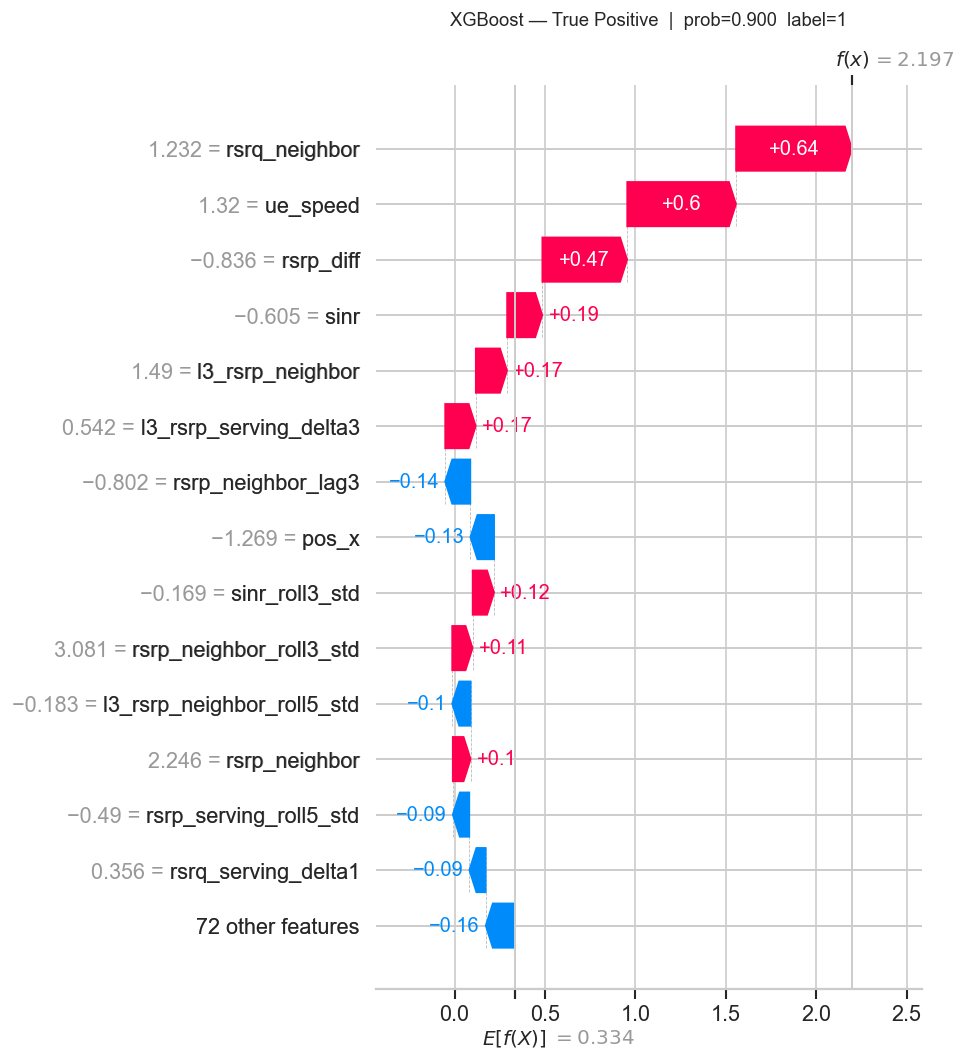

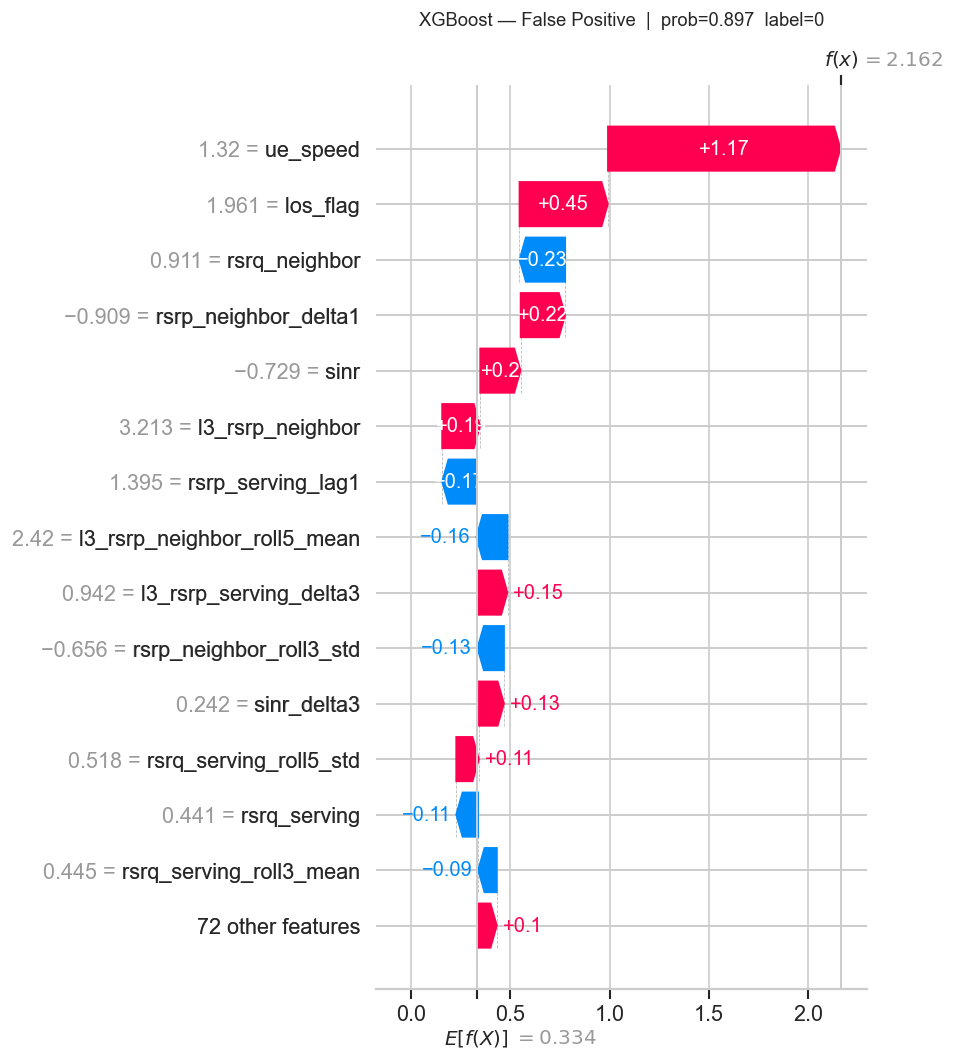

In [9]:
xgb_probs = xgb.predict_proba(X_bg_f32)[:, 1]
threshold = 0.5
preds = (xgb_probs >= threshold).astype(int)

tp_mask = (preds == 1) & (y_bg == 1)
fp_mask = (preds == 1) & (y_bg == 0)

if not tp_mask.any():
    print("No TP at threshold 0.5 — lowering to 0.3")
    threshold = 0.3
    preds = (xgb_probs >= threshold).astype(int)
    tp_mask = (preds == 1) & (y_bg == 1)
    fp_mask = (preds == 1) & (y_bg == 0)

tp_idx = int(np.where(tp_mask)[0][0])   # pick first TP
fp_idx = int(np.where(fp_mask)[0][0]) if fp_mask.any() else None

def waterfall_for(idx, title):
    sv = xgb_explainer(X_bg_f32[idx:idx+1])
    sv_raw = sv.values
    if sv_raw.ndim == 3: sv_raw = sv_raw[:, :, 1]
    bv = float(sv.base_values[0]) if sv.base_values.ndim > 0 else float(sv.base_values)
    if isinstance(bv, np.ndarray): bv = float(bv[1]) if len(bv) > 1 else float(bv[0])
    single = shap.Explanation(
        values        = sv_raw[0],
        base_values   = bv,
        data          = X_bg_f32[idx],
        feature_names = feat_cols,
    )
    plt.figure(figsize=(9, 5))
    shap.plots.waterfall(single, max_display=15, show=False)
    plt.title(title, pad=14, fontsize=11)
    plt.tight_layout()
    plt.show()

waterfall_for(tp_idx,
    f"XGBoost — True Positive  |  prob={xgb_probs[tp_idx]:.3f}  label=1")

if fp_idx is not None:
    waterfall_for(fp_idx,
        f"XGBoost — False Positive  |  prob={xgb_probs[fp_idx]:.3f}  label=0")

## 5 · Temporal SHAP — tracking one UE's explanation over time

Pick a single UE from the test set and plot how the SHAP values of the top-5 features
evolve across consecutive timesteps.  This shows *when* the model starts detecting the
upcoming handover in the signal dynamics.

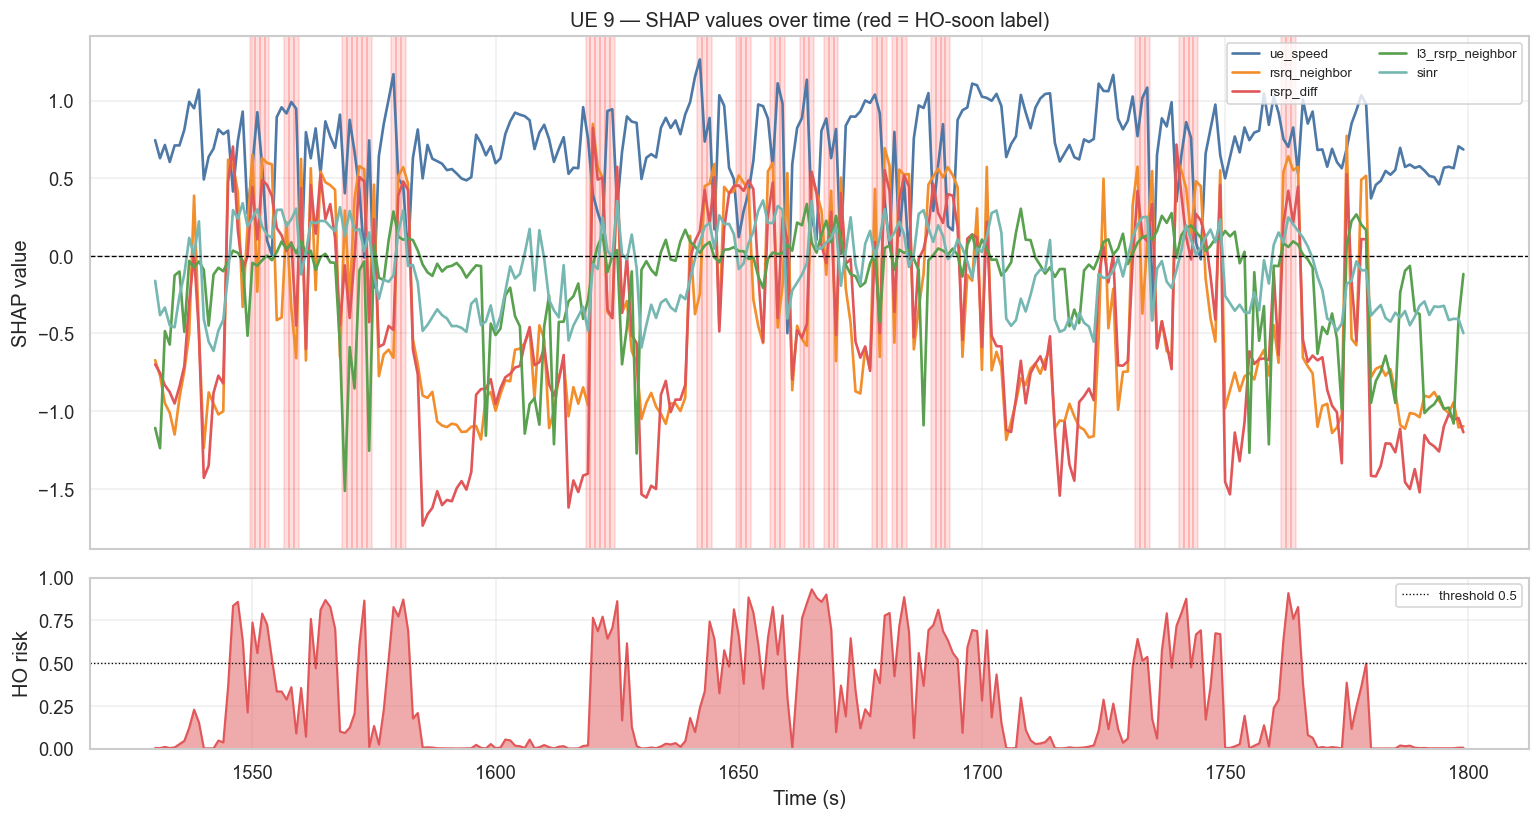

UE 9: 57 handover events in test window (270 timesteps)


In [10]:
# Pick the UE with the most positive-class timesteps in the test set
ue_counts = test.groupby("ue_id")["handover_soon"].sum()
target_ue = ue_counts.idxmax()
ue_df = test[test["ue_id"] == target_ue].sort_values("timestamp").reset_index(drop=True)

X_ue    = ue_df[feat_cols].fillna(0).values.astype(np.float32)
y_ue    = ue_df["handover_soon"].values
ts_ue   = ue_df["timestamp"].values

sv_ue = xgb_explainer.shap_values(X_ue)
if isinstance(sv_ue, list): sv_ue = sv_ue[1]
if sv_ue.ndim == 3: sv_ue = sv_ue[:, :, 1]

# Top-5 features by mean |SHAP| on this UE
top5_idx   = np.argsort(np.abs(sv_ue).mean(axis=0))[::-1][:5]
top5_names = [feat_cols[i] for i in top5_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

palette = ["#4e79a7","#f28e2b","#e15759","#59a14f","#76b7b2"]
for i, (fi, name, col) in enumerate(zip(top5_idx, top5_names, palette)):
    ax1.plot(ts_ue, sv_ue[:, fi], label=name[:35], color=col, lw=1.6)

# Shade handover periods
for t, label in zip(ts_ue, y_ue):
    if label == 1:
        ax1.axvspan(t - 0.5, t + 0.5, color="red", alpha=0.12)

ax1.axhline(0, color="black", lw=0.8, ls="--")
ax1.set_ylabel("SHAP value")
ax1.set_title(f"UE {target_ue} — SHAP values over time (red = HO-soon label)")
ax1.legend(fontsize=8, ncol=2)
ax1.grid(alpha=0.3)

probs_ue = xgb.predict_proba(X_ue)[:, 1]
ax2.fill_between(ts_ue, probs_ue, alpha=0.5, color="#e15759")
ax2.plot(ts_ue, probs_ue, color="#e15759", lw=1.2)
ax2.axhline(0.5, color="black", lw=0.8, ls=":", label="threshold 0.5")
ax2.set_ylabel("HO risk")
ax2.set_xlabel("Time (s)")
ax2.set_ylim(0, 1)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"UE {target_ue}: {int(y_ue.sum())} handover events in test window ({len(y_ue)} timesteps)")

## 6 · Key findings

Run the cell below to auto-generate a ranked summary from the computed SHAP values.

In [11]:
print("=" * 60)
print("  SHAP SUMMARY — Key Findings")
print("=" * 60)

xgb_importance = pd.Series(np.abs(xgb_shap).mean(axis=0), index=feat_cols)
top10 = xgb_importance.nlargest(10)

print("\n[XGBoost] Top-10 most influential features:")
for rank, (feat, val) in enumerate(top10.items(), 1):
    direction = "↑ HO risk" if xgb_shap[:, feat_cols.index(feat)].mean() > 0 else "↓ HO risk"
    print(f"  {rank:2d}. {feat:<40s}  mean|SHAP|={val:.4f}  ({direction})")

# Agreement: features in top-10 of all 3 models
lr_top10  = set(pd.Series(np.abs(lr_shap).mean(axis=0),  index=feat_cols).nlargest(10).index)
rf_top10  = set(pd.Series(np.abs(rf_shap).mean(axis=0),  index=feat_cols).nlargest(10).index)
xgb_top10 = set(top10.index)
agreement = lr_top10 & rf_top10 & xgb_top10

print(f"\n[Consensus] Features in top-10 of ALL three models ({len(agreement)}):")
for feat in sorted(agreement):
    print(f"  • {feat}")

  SHAP SUMMARY — Key Findings

[XGBoost] Top-10 most influential features:
   1. rsrq_neighbor                             mean|SHAP|=0.6884  (↓ HO risk)
   2. rsrp_diff                                 mean|SHAP|=0.6052  (↓ HO risk)
   3. ue_speed                                  mean|SHAP|=0.5763  (↓ HO risk)
   4. rsrq_serving                              mean|SHAP|=0.2584  (↓ HO risk)
   5. l3_rsrp_neighbor                          mean|SHAP|=0.2160  (↓ HO risk)
   6. sinr                                      mean|SHAP|=0.1972  (↓ HO risk)
   7. pos_y                                     mean|SHAP|=0.1486  (↓ HO risk)
   8. rsrq_serving_roll5_mean                   mean|SHAP|=0.1297  (↓ HO risk)
   9. rsrp_neighbor                             mean|SHAP|=0.1196  (↓ HO risk)
  10. pos_x                                     mean|SHAP|=0.1189  (↓ HO risk)

[Consensus] Features in top-10 of ALL three models (3):
  • rsrq_serving_roll5_mean
  • sinr
  • ue_speed
